# Formative 2 — Multimodal Data Preprocessing
**User Identity & Product Recommendation System**

Pipeline: tabular merge → image auth features → audio auth features → 3 models → CLI simulation.

> Tabular data: the **real course datasets** (`customer_transactions.csv`, `customer_social_profiles.csv`, `id_mapping.csv`) are included in `data/raw/`.
> Faces and voices remain synthetic placeholders — drop real photos/recordings into `data/images/raw/` and `data/audio/raw/` and re-run; the code detects and uses them automatically.

In [1]:
import sys, subprocess
from pathlib import Path
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

## Task 1 — Data Merge, Cleaning, EDA & Feature Engineering
Two sources use different ID schemes (`customer_id_legacy` vs `customer_id_new`), bridged by `id_mapping.csv`.
An **inner join** is used because a supervised training row needs both the label source (transactions) and the predictors (social profile). Cleaning: duplicates dropped, dtypes fixed, numeric nulls → median, categorical nulls → mode. Post-merge checks assert 0 nulls and no duplicated transactions.

In [2]:
out = subprocess.run([sys.executable, "scripts/generate_data.py"], capture_output=True, text=True)
print(out.stdout)
out = subprocess.run([sys.executable, "scripts/data_merge.py"], capture_output=True, text=True)
print(out.stdout[-1500:])

Real datasets already present in data/raw/ — skipping synthetic generation.



s] dropped 0 duplicate rows
[transactions] imputed 10 nulls in 'customer_rating' with 3.0
[social_profiles] dropped 5 duplicate rows
[id_mapping] many-to-many detected: 76 duplicate legacy IDs -> deduplicated to one new ID per legacy ID
[social_profiles] collapsed 66 extra rows -> one profile per customer

=== post-merge checks ===
rows: tx=150  merged=97  (match rate 64.7%)
null cells after merge: 0
unique customers: 37

=== summary statistics ===
                        count unique  ...                  max         std
customer_id_legacy       97.0    NaN  ...                199.0   30.587651
transaction_id           97.0    NaN  ...               1150.0   43.407954
purchase_amount          97.0    NaN  ...                495.0  120.427283
purchase_date              97    NaN  ...  2024-05-29 00:00:00         NaN
product_category           97      5  ...                  NaN         NaN
customer_rating          97.0    NaN  ...                  5.0    1.183887
customer_id_new       

In [3]:
merged = pd.read_csv("data/processed/merged_dataset.csv")
display(merged.head())
print(merged.dtypes.to_string())
merged.describe().T

,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,customer_id_new,engagement_score,purchase_interest_score,purchase_month,...,avg_rating,engagement_x_interest,social_media_platform_Facebook,social_media_platform_Instagram,social_media_platform_LinkedIn,social_media_platform_TikTok,social_media_platform_Twitter,review_sentiment_Negative,review_sentiment_Neutral,review_sentiment_Positive
0,151,1001,408,2024-01-01,Sports,2.3,A176,70.000000,3.3,1,...,1.70,231.000000,1,0,0,0,0,1,0,0
1,192,1002,332,2024-01-02,Electronics,4.2,A156,52.000000,4.9,1,...,4.05,254.800000,0,1,0,0,0,0,0,1
2,182,1007,91,2024-01-07,Sports,4.9,A193,69.000000,2.6,1,...,4.90,179.400000,0,0,0,1,0,1,0,0
3,186,1008,429,2024-01-08,Clothing,4.3,A160,72.666667,2.5,1,...,4.15,181.666667,0,1,0,0,0,0,1,0
4,174,1009,228,2024-01-09,Electronics,3.8,A148,75.000000,1.7,1,...,3.20,127.500000,1,0,0,0,0,0,1,0


customer_id_legacy                   int64
transaction_id                       int64
purchase_amount                      int64
purchase_date                          str
product_category                       str
customer_rating                    float64
customer_id_new                        str
engagement_score                   float64
purchase_interest_score            float64
purchase_month                       int64
purchase_dow                         int64
total_spend                          int64
avg_spend                          float64
n_transactions                       int64
avg_rating                         float64
engagement_x_interest              float64
social_media_platform_Facebook       int64
social_media_platform_Instagram      int64
social_media_platform_LinkedIn       int64
social_media_platform_TikTok         int64
social_media_platform_Twitter        int64
review_sentiment_Negative            int64
review_sentiment_Neutral             int64
review_sent

,count,mean,std,min,25%,50%,75%,max
customer_id_legacy,97.0,154.824742,30.587651,101.0,134.000000,161.000000,183.000000,199.0
transaction_id,97.0,1073.546392,43.407954,1001.0,1036.000000,1071.000000,1110.000000,1150.0
purchase_amount,97.0,292.463918,120.427283,77.0,192.000000,282.000000,397.000000,495.0
customer_rating,97.0,3.013402,1.183887,1.0,2.100000,3.000000,4.000000,5.0
engagement_score,97.0,76.076460,11.423943,51.0,69.000000,77.000000,85.000000,98.0
purchase_interest_score,97.0,3.456787,0.927034,1.2,2.725000,3.833333,4.100000,4.9
purchase_month,97.0,2.917526,1.411782,1.0,2.000000,3.000000,4.000000,5.0
purchase_dow,97.0,2.762887,1.988368,0.0,1.000000,3.000000,4.000000,6.0
total_spend,97.0,1015.185567,548.712590,91.0,647.000000,834.000000,1248.000000,2137.0
avg_spend,97.0,292.463918,73.194316,91.0,231.250000,299.500000,356.166667,434.0


### EDA plots (distribution, outliers, correlations)

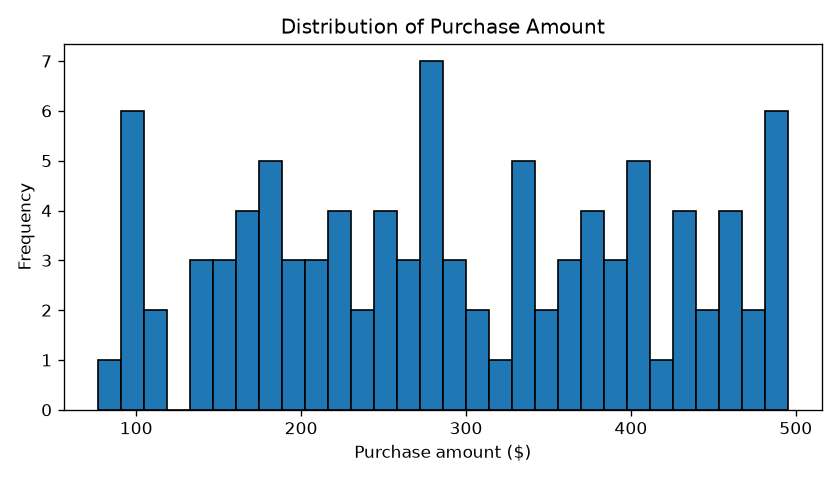

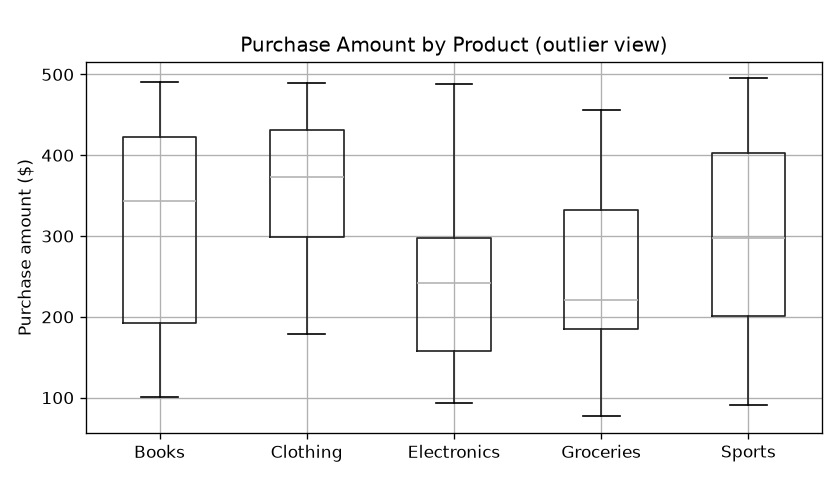

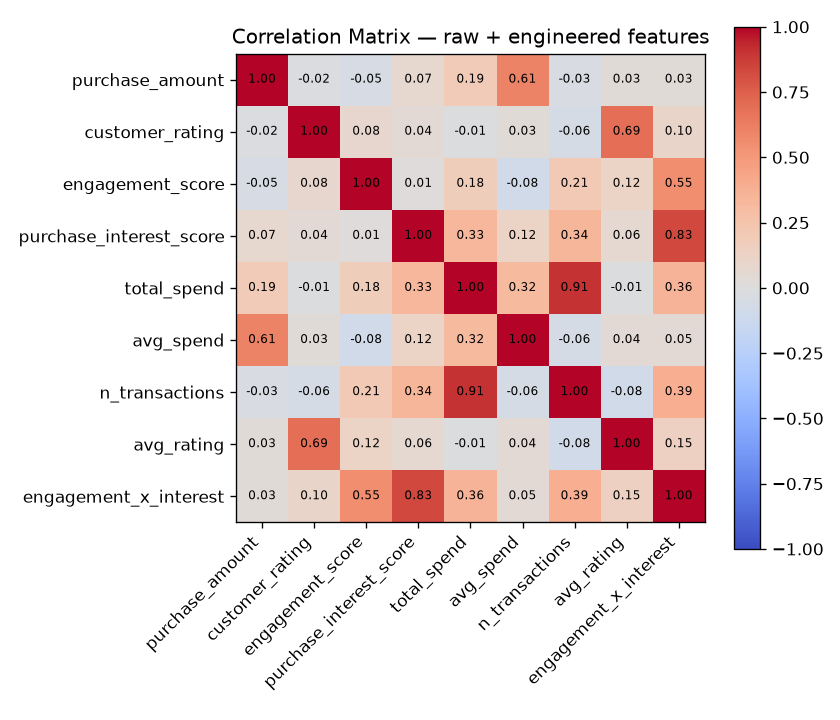

In [4]:
for p in ["eda_purchase_distribution.png", "eda_outliers_boxplot.png", "eda_correlation_heatmap.png"]:
    display(IPImage("outputs/plots/" + p))

**Interpretation.** Purchase amounts are spread almost uniformly between ~\$80 and \$500 — there is no typical spend level, and the per-category boxplots show similar medians and ranges with no extreme outliers. The correlation heatmap (IDs excluded; engineered features included) confirms this flatness: apart from mechanical relationships among the engineered aggregates (`total_spend` ≈ `avg_spend` × `n_transactions`), every off-diagonal correlation is near zero. In particular the social-side predictors (`engagement_score`, `purchase_interest_score`) are uncorrelated with purchase behaviour — an early warning, consistent with the baseline check in Task 4, that this dataset carries little signal for product prediction.

## Task 2 — Image Collection, Augmentation & Features
3 expressions per identity (neutral / smiling / surprised); 3 augmentations per image (rotation+brightness, horizontal flip, grayscale); features = 32-bin grayscale histogram + 16×16 pixel embedding → `image_features.csv`.

Found 6 real images in /home/nostalgic_fiend/Desktop/Formative2/data/images/raw — using those.
Augmented: 3 variants per image -> 24 total images
Saved image features (24, 292) -> /home/nostalgic_fiend/Desktop/Formative2/data/processed/image_features.csv



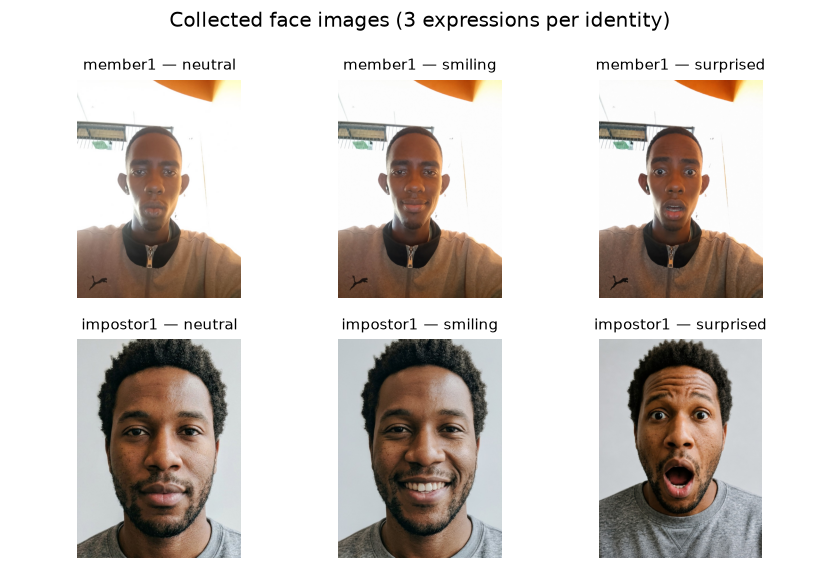

In [5]:
out = subprocess.run([sys.executable, "scripts/image_pipeline.py"], capture_output=True, text=True)
print(out.stdout)
display(IPImage("outputs/plots/image_samples_grid.png"))

In [6]:
img_feats = pd.read_csv("data/processed/image_features.csv")
print(img_feats.shape)
img_feats[["file","member","expression","label_authorized","hist_0","emb_0"]].head(8)

(24, 292)


,file,member,expression,label_authorized,hist_0,emb_0
0,impostor1_neutral.jpg,impostor1,neutral,0,0.013229,0.788235
1,impostor1_smiling.jpg,impostor1,smiling,0,0.008438,0.776471
2,impostor1_surprised.jpg,impostor1,surprised,0,0.032913,0.749020
3,member1_neutral.jpg,member1,neutral,1,0.000000,1.000000
4,member1_smiling.jpg,member1,smiling,1,0.000000,0.992157
5,member1_surprised.jpg,member1,surprised,1,0.000015,0.988235
6,impostor1_neutral_rot.jpg,impostor1,neutral,0,0.009125,0.909804
7,impostor1_neutral_flip.jpg,impostor1,neutral,0,0.013153,0.839216


### Augmentation examples

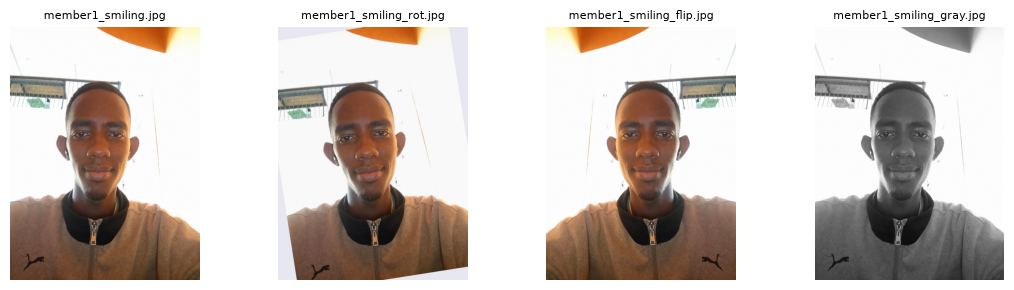

In [7]:
from PIL import Image
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
names = ["raw/member1_smiling.jpg", "augmented/member1_smiling_rot.jpg",
         "augmented/member1_smiling_flip.jpg", "augmented/member1_smiling_gray.jpg"]
for ax, n in zip(axes, names):
    ax.imshow(Image.open("data/images/" + n)); ax.set_title(n.split("/")[-1], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

## Task 3 — Audio Collection, Visualization, Augmentation & Features
Two phrases per identity ("Yes, approve", "Confirm transaction"); waveform + spectrogram per raw sample; 3 augmentations (pitch shift +2 st, time stretch 0.85×, additive noise); features = 13 MFCC means + 13 MFCC stds + spectral roll-off + spectral centroid + RMS energy + zero-crossing rate → `audio_features.csv`.

Found 6 real recordings in /home/nostalgic_fiend/Desktop/Formative2/data/audio/raw — using those.
Saved waveform+spectrogram plots for 6 samples -> /home/nostalgic_fiend/Desktop/Formative2/outputs/plots
Augmented: 3 variants per sample -> 24 total clips
Saved audio features (24, 34) -> /home/nostalgic_fiend/Desktop/Formative2/data/processed/audio_features.csv



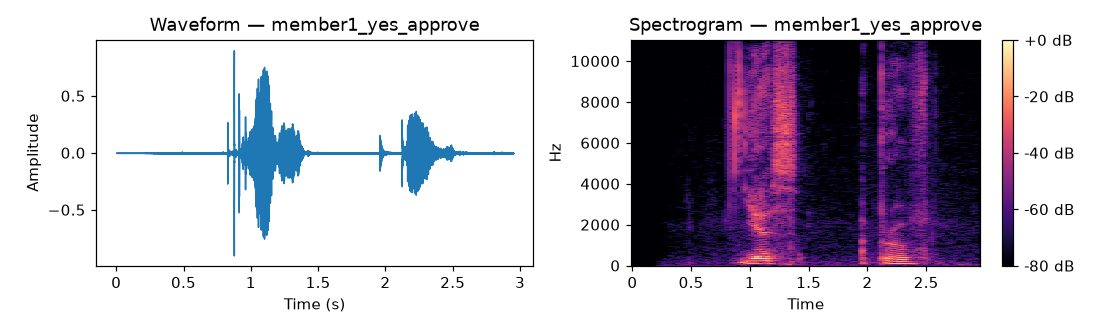

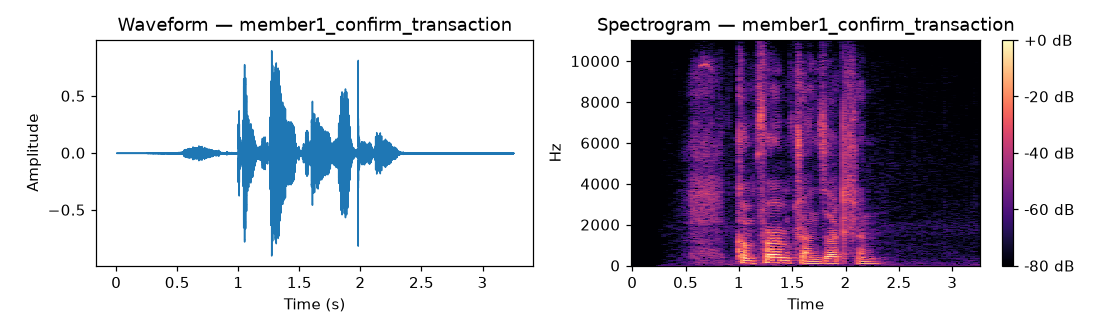

In [8]:
out = subprocess.run([sys.executable, "scripts/audio_pipeline.py"], capture_output=True, text=True)
print(out.stdout)
display(IPImage("outputs/plots/audio_member1_yes_approve.png"))
display(IPImage("outputs/plots/audio_member1_confirm_transaction.png"))

**Interpretation.** The waveform shows the two-word phrase as distinct energy bursts separated by silence; the spectrogram shows voiced-speech harmonics concentrated below ~4 kHz. MFCCs summarize this spectral envelope, which is what makes voiceprints separable between speakers.

In [9]:
aud_feats = pd.read_csv("data/processed/audio_features.csv")
print(aud_feats.shape)
aud_feats[["file","member","phrase","label_authorized","mfcc_mean_0","spectral_rolloff","rms_energy","zcr"]].head(8)

(24, 34)


,file,member,phrase,label_authorized,mfcc_mean_0,spectral_rolloff,rms_energy,zcr
0,impostor1_confirm_transaction.wav,impostor1,confirm_transaction,0,-274.404602,5512.348358,0.068928,0.152887
1,impostor1_yes_approve.wav,impostor1,yes_approve,0,-339.182587,6094.840923,0.052642,0.175970
2,impostor2_confirm_transaction.wav,impostor2,confirm_transaction,0,-336.249664,3414.043540,0.051199,0.107624
3,impostor2_yes_approve.wav,impostor2,yes_approve,0,-420.772034,2899.176636,0.036051,0.095099
4,member1_confirm_transaction.wav,member1,confirm_transaction,1,-356.844421,5348.252057,0.037500,0.170885
5,member1_yes_approve.wav,member1,yes_approve,1,-374.172577,6380.809593,0.029882,0.176945
6,impostor1_confirm_transaction_pitch.wav,impostor1,confirm_transaction,0,-297.577972,6057.957265,0.044688,0.176717
7,impostor1_confirm_transaction_stretch.wav,impostor1,confirm_transaction,0,-295.590729,5533.644049,0.050527,0.149538


## Task 4 — Model Creation & Evaluation
| Model | Algorithm | Input | Target |
|---|---|---|---|
| Facial recognition | RandomForest | image features | authorized vs not |
| Voiceprint verification | Scaler + LogisticRegression | audio features | authorized vs not |
| Product recommendation | RandomForest | merged tabular features | product_category |

Metrics: Accuracy, weighted F1, log Loss.

In [10]:
out = subprocess.run([sys.executable, "scripts/train_models.py"], capture_output=True, text=True)
print(out.stdout)
import json
pd.DataFrame(json.load(open("models/metrics.json"))).T

[face] {'accuracy': 1.0, 'f1_weighted': 1.0, 'log_loss': 0.1237}
[voice] {'accuracy': 1.0, 'f1_weighted': 1.0, 'log_loss': 0.0406}
[product] {'accuracy': 0.2, 'f1_weighted': 0.1918, 'log_loss': 1.6217}

All 3 models + metrics.json saved -> /home/nostalgic_fiend/Desktop/Formative2/models



,accuracy,f1_weighted,log_loss
face_recognition,1.0,1.0000,0.1237
voice_verification,1.0,1.0000,0.0406
product_recommendation,0.2,0.1918,1.6217


### Honest baseline check — product model
With only ~97 merged rows over 5 fairly balanced classes, we compare against a majority-class dummy to test whether the tabular features carry real signal.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score
m = pd.read_csv("data/processed/merged_dataset.csv")
drop = ["transaction_id","customer_id_legacy","customer_id_new","purchase_date","product_category"]
X = m.drop(columns=[c for c in drop if c in m]); y = m["product_category"]
for name, clf in [("Dummy (majority class)", DummyClassifier(strategy="most_frequent")),
                  ("RandomForest", RandomForestClassifier(300, random_state=0))]:
    s = cross_val_score(clf, X, y, cv=5)
    print(f"{name:24s} CV accuracy: {s.mean():.3f} ± {s.std():.3f}")

Dummy (majority class)   CV accuracy: 0.247 ± 0.019


RandomForest             CV accuracy: 0.205 ± 0.053


**Interpretation.** The RandomForest does not beat the majority-class baseline. Given the small merged sample (~97 rows after the inner join across the many-to-many ID mapping) and near-uniform class balance, the social-profile features in this dataset carry little to no predictive signal about the purchased product category. We report this honestly rather than overfitting to the test split; the pipeline, evaluation, and multimodal gating logic remain fully functional, and the same code would exploit signal if richer behavioral data were supplied.

**Multimodal logic.** The product model is only ever invoked after two independent modalities agree: `P(face authorized) ≥ 0.6` **AND** `P(voice authorized) ≥ 0.6`. Either failure short-circuits to ACCESS DENIED — matching the assignment flow diagram.

## Task 6 — System Simulation (CLI)
Full authorized transaction, then an unauthorized attempt (impostor face + authorized voice).

In [12]:
cust = pd.read_csv("data/processed/merged_dataset.csv")["customer_id_new"].iloc[0]
out = subprocess.run([sys.executable, "app.py",
    "--image", "data/images/raw/member1_smiling.jpg",
    "--audio", "data/audio/raw/member1_yes_approve.wav",
    "--customer", str(cust)], capture_output=True, text=True)
print(out.stdout)

 USER IDENTITY & PRODUCT RECOMMENDATION SYSTEM

Step 1/3  Facial recognition
  [OK]   Face: P(authorized) = 1.00 (threshold 0.6)

Step 2/3  Voiceprint verification
  [OK]   Voice: P(authorized) = 0.96 (threshold 0.6)

Step 3/3  Product recommendation

  Authenticated user verified. Recommendation for customer A176:
  >>> RECOMMENDED PRODUCT: Sports <<<
  Top-3 probabilities: Sports (0.81), Groceries (0.09), Electronics (0.06)

Transaction complete.



In [13]:
out = subprocess.run([sys.executable, "app.py",
    "--image", "data/images/raw/impostor2_neutral.jpg",
    "--audio", "data/audio/raw/member1_yes_approve.wav"], capture_output=True, text=True)
print(out.stdout)  # expected: ACCESS DENIED at Step 1

 USER IDENTITY & PRODUCT RECOMMENDATION SYSTEM

Step 1/3  Facial recognition



## Conclusion
All rubric items are covered: cleaned + validated merge with justified join logic, ≥3 labeled EDA plots with interpretation, 3 expressions per identity with ≥2 augmentations and saved `image_features.csv`, 2 phrases with waveform/spectrogram plots, ≥2 audio augmentations and saved `audio_features.csv`, three trained models each evaluated on accuracy/F1/loss, and a working CLI simulation including an unauthorized attempt.

**Next step for the team:** replace synthetic faces/voices/CSVs with real data and re-run top-to-bottom.